In [3]:
import pandas as pd
df = pd.read_excel("OUTPUT_Unione_Aida_Registro .xlsx")
df.head()

,codice_fiscale,ragione_sociale,codice_ateco,comune,provincia,regione,forma_giuridica,ateco_sezione_cod,ateco_sezione_desc,ateco_divisione_cod,...,Ricavi vendite e prestazioni migl EUR 2023,Ricavi vendite e prestazioni migl EUR 2022,Ricavi vendite e prestazioni migl EUR 2021,Ricavi vendite e prestazioni migl EUR 2020,Capitale sociale migl EUR 2024,Capitale sociale migl EUR 2023,Capitale sociale migl EUR 2022,Capitale sociale migl EUR 2021,Capitale sociale migl EUR 2020,Dipendenti (Ultimo anno) Ultimo anno disp.
0,2892000429,TERZA BASE S.R.L.,107110,SENIGALLIA,AN,MARCHE,SOCIETA' A RESPONSABILITA' LIMITATA,C,ATTIVITA' MANIFATTURIERE,C 10,...,262.096,66.14,0,n.d.,190.8,190.8,115.8,91.9,n.d.,10
1,11331520962,FOOLFARM S.P.A.,621000,MILANO,MI,LOMBARDIA,SOCIETA' PER AZIONI,J,SERVIZI DI INFORMAZIONE E COMUNICAZIONE,J 62,...,519.163,734.579,262.529,0.713,187.58,171.393,171.393,140.7,135.7,11
2,15991751007,WETACOO S.R.L.,621000,ROMA,RM,LAZIO,SOCIETA' A RESPONSABILITA' LIMITATA,J,SERVIZI DI INFORMAZIONE E COMUNICAZIONE,J 62,...,886.613,485.726,104.779,n.d.,11.766,10.943,10.943,10,n.d.,27
3,4457480160,BCC STUDIO S.R.L.,621000,BERGAMO,BG,LOMBARDIA,SOCIETA' A RESPONSABILITA' LIMITATA,J,SERVIZI DI INFORMAZIONE E COMUNICAZIONE,J 62,...,364.362,60,10.4,0,40,40,40,0.001,0.001,0
4,7205120483,MEETALPHA SOCIETA' A RESPONSABILITA' LIMITATA,621000,FIRENZE,FI,TOSCANA,SOCIETA' A RESPONSABILITA' LIMITATA,J,SERVIZI DI INFORMAZIONE E COMUNICAZIONE,J 62,...,70,0,n.d.,n.d.,10.09,10.09,10.09,n.d.,n.d.,2


In [7]:
df.columns.to_list()

['codice_fiscale',
 'ragione_sociale',
 'codice_ateco',
 'comune',
 'provincia',
 'regione',
 'forma_giuridica',
 'ateco_sezione_cod',
 'ateco_sezione_desc',
 'ateco_divisione_cod',
 'ateco_divisione_desc',
 'macro_settore',
 'settore',
 'sito_linkedin',
 'sito_web',
 'tipo',
 'percentuale_completamento',
 'fascia_completamento',
 'aggiornamento_al',
 'data costituzione',
 'data dichiarazione',
 'data inizio esercizio effettivo',
 'data iscrizione registro imprese',
 'data iscrizione sezione startup',
 'legale_rappresentante',
 'data_firma_digitale',
 'impresa_costituita',
 'classe_addetti',
 'classe_addetti_codice',
 'classe_capitale',
 'classe_capitale_codice',
 'classe_valore_produzione',
 'classe_valore_produzione_codice',
 'finanza',
 'finanza_ammontare_euro',
 'finanza_data_annuncio',
 'finanza_data_chiusura',
 'finanza_investitori',
 'vocazione sociale',
 'alto valore tecnologico',
 'brevetto',
 'forza lavoro con titoli',
 'possesso di brevetti',
 'possesso_titoli_ip',
 'spese i

### DISTRIBUZIONE GEOGRAFICA DELLE STARTUP: COME SI DISTRIBUISCONO SUL TERRITORIO ITALIANO

In [20]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# ── 1. PULIZIA DATI ──────────────────────────────────────────────────────────
df['Indirizzo sede legale - Latitudine']  = pd.to_numeric(df['Indirizzo sede legale - Latitudine'],  errors='coerce')
df['Indirizzo sede legale - Longitudine'] = pd.to_numeric(df['Indirizzo sede legale - Longitudine'], errors='coerce')
df['ricavi_2024'] = pd.to_numeric(df['Ricavi vendite e prestazioni migl EUR 2024'], errors='coerce')

df['anno_cost'] = pd.to_datetime(df['data costituzione'], errors='coerce').dt.year.astype('Int64')

df['ricavi_fmt'] = df['ricavi_2024'].apply(
    lambda x: f"{x*1000:,.0f} €".replace(",", ".") if pd.notna(x) else "n.d."
)

df['tooltip'] = (
    "<b>" + df['ragione_sociale'].fillna('N/D') + "</b><br>" +
    "📅 Costituita: "    + df['anno_cost'].astype(str) + "<br>" +
    "📍 Regione: "       + df['regione'].fillna('N/D').str.title() + "<br>" +
    "🏭 Macro settore: " + df['macro_settore'].fillna('N/D') + "<br>" +
    "👥 Addetti: "       + df['classe_addetti'].fillna('N/D') + "<br>" +
    "🚀 Stadio: "        + df['stadio_startup'].fillna('N/D') + "<br>" +
    "💶 Ricavi 2024: "   + df['ricavi_fmt']
)

df_plot = df.dropna(subset=['Indirizzo sede legale - Latitudine', 'Indirizzo sede legale - Longitudine'])

# ── 2. COLORI PER REGIONE ────────────────────────────────────────────────────
df_plot = df_plot.copy()
df_plot['regione_title'] = df_plot['regione'].str.title()
regioni_presenti = sorted(df_plot['regione_title'].unique())

palette = (
    px.colors.qualitative.Plotly +
    px.colors.qualitative.Dark24 +
    px.colors.qualitative.Alphabet
)
color_map = {r: palette[i % len(palette)] for i, r in enumerate(regioni_presenti)}

# Regioni mancanti
tutte = ['Valle D\'Aosta','Piemonte','Liguria','Lombardia','Trentino-Alto Adige',
         'Veneto','Friuli-Venezia Giulia','Emilia-Romagna','Toscana','Marche',
         'Umbria','Lazio','Abruzzo','Molise','Campania','Puglia',
         'Basilicata','Calabria','Sicilia','Sardegna']
mancanti = [r for r in tutte if r not in regioni_presenti]
print("📍 Regioni senza startup:", mancanti)

# ── 3. FIGURA ────────────────────────────────────────────────────────────────
fig = go.Figure()

for regione in regioni_presenti:
    subset = df_plot[df_plot['regione_title'] == regione]
    fig.add_trace(go.Scattergeo(
        lat=subset['Indirizzo sede legale - Latitudine'],
        lon=subset['Indirizzo sede legale - Longitudine'],
        mode='markers',
        name=regione,
        marker=dict(
            size=9,
            color=color_map[regione],
            opacity=0.88,
            line=dict(width=0.8, color='white')
        ),
        hovertemplate=subset['tooltip'] + "<extra></extra>",
        legendgroup=regione,
        showlegend=True
    ))

# ── 4. STILE MAPPA ───────────────────────────────────────────────────────────
fig.update_geos(
    visible=True,
    resolution=50,
    scope="europe",
    lonaxis_range=[6.5, 18.8],
    lataxis_range=[36.0, 47.2],
    showland=True,        landcolor="#e8e0d5",
    showocean=True,       oceancolor="#b8d4e8",
    showlakes=True,       lakecolor="#c5dcea",
    showcountries=True,   countrycolor="#9a9a8a",   countrywidth=0.8,
    showcoastlines=True,  coastlinecolor="#7a8a7a", coastlinewidth=0.8,
    showsubunits=True,    subunitcolor="#c0b8a8",   subunitwidth=0.5,
    showframe=False,
    bgcolor="rgba(0,0,0,0)",
)

fig.update_layout(
    paper_bgcolor="#f7f4ef",
    title=dict(
        text="🇮🇹 Distribuzione geografica delle startup italiane",
        font=dict(size=18, family="Georgia, serif", color="#2c2c2c"),
        x=0.5, xanchor='center', pad=dict(t=15)
    ),
    legend=dict(
        title=dict(
            text="<b>Regione</b><br><i>clicca per isolare</i>",
            font=dict(size=12, family="Georgia, serif")
        ),
        bgcolor="rgba(247,244,239,0.92)",
        bordercolor="#c8bfb0", borderwidth=1,
        font=dict(size=11, family="Georgia, serif"),
        itemclick="toggleothers",
        itemdoubleclick="toggle",
        x=1.01, y=0.5, xanchor='left', yanchor='middle'
    ),
    margin=dict(l=10, r=170, t=55, b=10),
    height=660,
)

fig.show()

📍 Regioni senza startup: ["Valle D'Aosta"]


### DISTRIBUZIONE DELLE STARTUP PER MACRO SETTORE & RICAVI PER MACRO SETTORE

In [52]:
import plotly.graph_objects as go
import pandas as pd

# ── 1. PULIZIA ───────────────────────────────────────────────
df['ricavi_2024'] = pd.to_numeric(
    df['Ricavi vendite e prestazioni migl EUR 2024'], errors='coerce'
) * 1000

df['macro_settore'] = df['macro_settore'].fillna('Non classificato')

# ── 2. AGGREGAZIONE ──────────────────────────────────────────
agg = (
    df.groupby('macro_settore')
    .agg(
        n_startup    = ('ragione_sociale', 'count'),
        ricavi_medi  = ('ricavi_2024',     'mean'),
        ricavi_totali= ('ricavi_2024',     'sum'),
    )
    .reset_index()
    .sort_values('n_startup', ascending=True)
)

agg['ricavi_medi_fmt'] = agg['ricavi_medi'].apply(
    lambda x: f"{x:,.0f} €".replace(",", ".") if pd.notna(x) else "n.d."
)
agg['ricavi_totali_fmt'] = agg['ricavi_totali'].apply(
    lambda x: f"{x:,.0f} €".replace(",", ".") if pd.notna(x) else "n.d."
)

# ── 3. ETICHETTE SU DUE RIGHE ────────────────────────────────
def wrap_plotly(text, max_len=30):
    if len(text) <= max_len:
        return text
    mid = len(text) // 2
    split = text.rfind(' ', 0, mid + 15)
    if split == -1:
        split = mid
    return text[:split] + '<br>' + text[split+1:]

agg['label_breve'] = agg['macro_settore'].apply(wrap_plotly)

# ── 4. FIGURA ────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Bar(
    y=agg['label_breve'],
    x=agg['n_startup'],
    orientation='h',
    name='N° startup',
    marker=dict(
        color=agg['ricavi_medi'],
        colorscale=[
            [0.0, "#cfe2f3"],
            [0.3, "#6baed6"],
            [0.6, "#f47c3c"],
            [1.0, "#c0392b"],
        ],
        colorbar=dict(
            title=dict(
                text="Ricavi medi<br>2024 (€)",
                font=dict(size=11, family="Georgia, serif")
            ),
            tickformat=",.0f",
            thickness=14, len=0.5,
            bgcolor="rgba(247,244,239,0.9)",
            bordercolor="#c8bfb0", borderwidth=1,
            x=1.01,
        ),
        line=dict(width=0.5, color='white'),
    ),
    customdata=agg[['macro_settore', 'n_startup', 'ricavi_medi_fmt', 'ricavi_totali_fmt']].values,
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "🏢 N° startup: %{customdata[1]}<br>"
        "💶 Ricavi medi 2024: %{customdata[2]}<br>"
        "💰 Ricavi totali 2024: %{customdata[3]}"
        "<extra></extra>"
    ),
    text=agg['n_startup'],
    textposition='inside',
    textfont=dict(color='white', size=11, family="Georgia, serif"),
    insidetextanchor='end',
))

# ── 5. LAYOUT ────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text="📊 Startup per macro settore — barre = n° startup, colore = ricavi medi 2024",
        font=dict(size=14, family="Georgia, serif", color="#2c2c2c"),
        x=0.5, xanchor='center', pad=dict(t=10)
    ),
    xaxis=dict(
        title="N° startup",
        title_font=dict(size=12, family="Georgia, serif"),
        tickfont=dict(size=11, family="Georgia, serif"),
        gridcolor="#e0dbd4",
        showline=True, linecolor="#c8bfb0",
    ),
    yaxis=dict(
        title="",
        tickfont=dict(size=11, family="Georgia, serif"),
        automargin=True,
        ticklabeloverflow='allow',
    ),
    paper_bgcolor="#f7f4ef",
    plot_bgcolor="#faf8f4",
    margin=dict(l=20, r=120, t=60, b=40),
    height=max(400, len(agg) * 65),   # più alto per etichette su due righe
    showlegend=False,
    bargap=0.3,
)

fig.show()

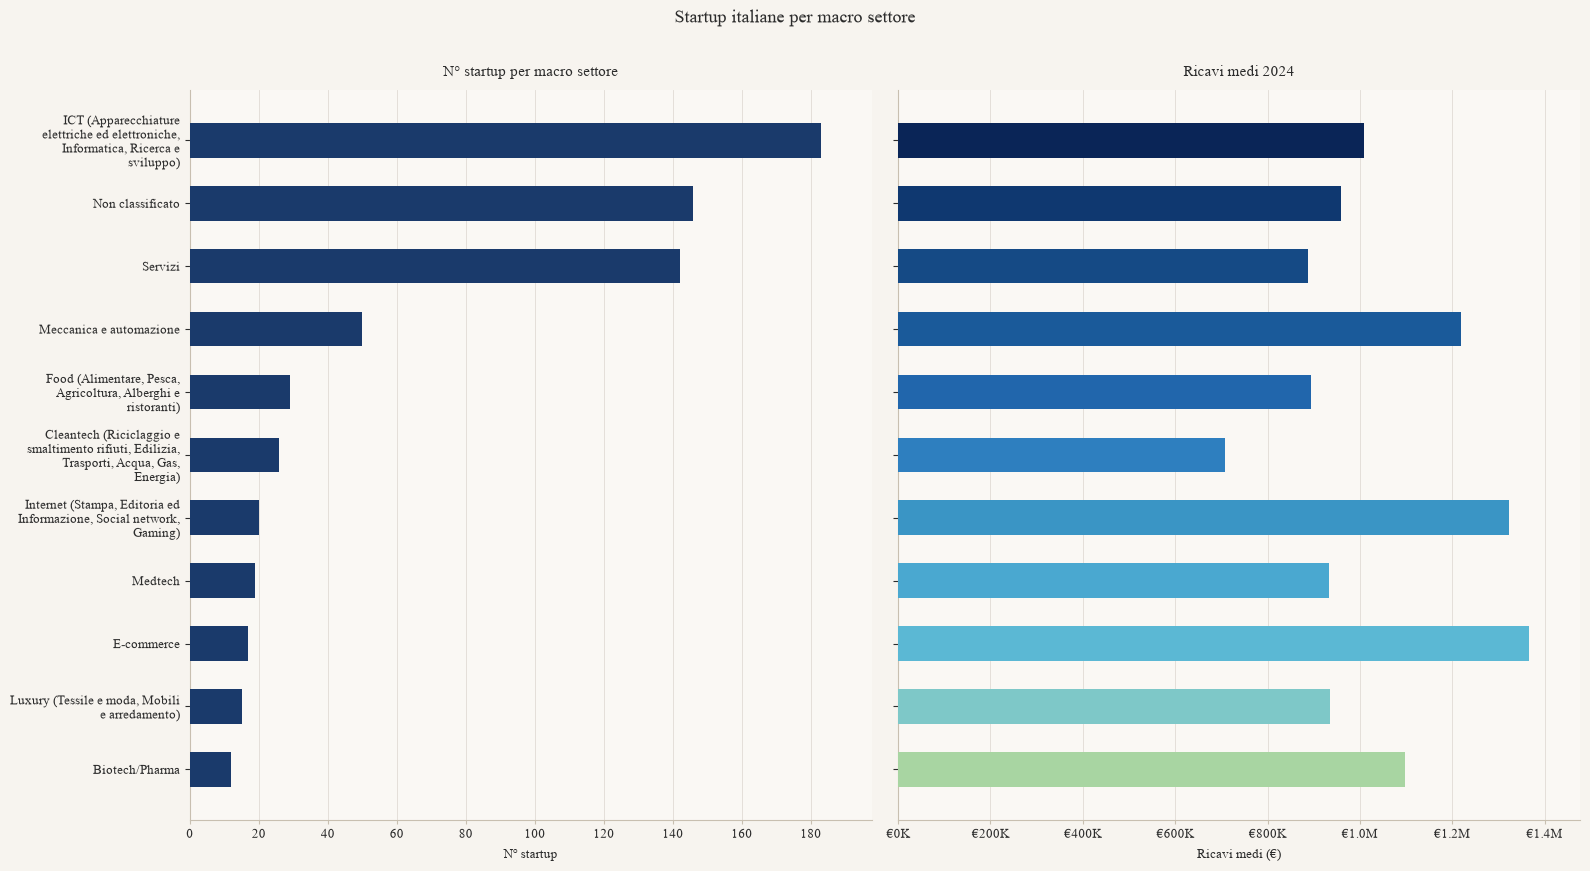

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import textwrap
import pandas as pd

# ── 1. PULIZIA & AGGREGAZIONE ────────────────────────────────
df['ricavi_2024'] = pd.to_numeric(
    df['Ricavi vendite e prestazioni migl EUR 2024'], errors='coerce'
) * 1000

df['macro_settore'] = df['macro_settore'].fillna('Non classificato')

agg = (
    df.groupby('macro_settore')
    .agg(
        n_startup  = ('ragione_sociale', 'count'),
        ricavi_medi= ('ricavi_2024',     'mean'),
    )
    .reset_index()
    .sort_values('n_startup', ascending=True)  # ascending=True → barra più lunga in cima
)

# ── 2. PALETTE ────────────────────────────────────────────────
# I colori seguono l'ordine delle righe, quindi sono coerenti tra i due pannelli
RIGHT_COLORS = [
    "#a8d5a2", "#7ec8c8", "#5bb8d4", "#4aa8d0", "#3a95c5",
    "#2e7fbf", "#2166ac", "#1a5a9a", "#154a85", "#0f3870", "#0a2557",
]
n = len(agg)
colors = (RIGHT_COLORS * ((n // len(RIGHT_COLORS)) + 1))[:n]
BAR_COLOR_LEFT = "#1a3a6b"

labels = [textwrap.fill(s, width=30) for s in agg['macro_settore']]
y_pos  = np.arange(n)

FONT        = "Times New Roman"
BG_FIG      = "#f7f4ef"
BG_AX       = "#faf8f4"
TEXT_COLOR  = "#2c2c2c"
GRID_COLOR  = "#e0dbd4"
SPINE_COLOR = "#c8bfb0"

# ── 3. FIGURA ─────────────────────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(
    1, 2,
    figsize=(16, max(6, n * 0.78)),
    facecolor=BG_FIG,
)
fig.subplots_adjust(wspace=0.06)

for ax in (ax_l, ax_r):
    ax.set_facecolor(BG_AX)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_color(SPINE_COLOR)

# ── Pannello sinistro: N° startup ────────────────────────────
ax_l.barh(y_pos, agg['n_startup'], color=BAR_COLOR_LEFT,
          height=0.55, zorder=3)

ax_l.set_yticks(y_pos)
ax_l.set_yticklabels(labels, fontsize=9.5, fontfamily=FONT,
                     color=TEXT_COLOR)
ax_l.set_title("N° startup per macro settore", fontsize=11,
               fontfamily=FONT, pad=10, color=TEXT_COLOR)

max_n = agg['n_startup'].max()
step  = 50 if max_n > 200 else (20 if max_n > 50 else 10)
ticks_l = np.arange(0, max_n + step, step)
ax_l.set_xticks(ticks_l)
ax_l.set_xticklabels([str(int(t)) for t in ticks_l],
                     fontsize=9, fontfamily=FONT, color=TEXT_COLOR)
ax_l.set_xlabel("N° startup", fontsize=9.5, fontfamily=FONT,
                labelpad=6, color=TEXT_COLOR)
ax_l.tick_params(axis='x', length=3, color=SPINE_COLOR)
ax_l.set_xlim(0, max_n * 1.08)
ax_l.spines[['top', 'right']].set_visible(False)
ax_l.grid(axis='x', color=GRID_COLOR, linewidth=0.6, zorder=0)

# ── Pannello destro: Ricavi medi ─────────────────────────────
# stesso y_pos e stesso ordine → coerenza garantita
ax_r.barh(y_pos, agg['ricavi_medi'], color=colors,
          height=0.55, zorder=3)

ax_r.set_yticks(y_pos)
ax_r.set_yticklabels([])
ax_r.set_title("Ricavi medi 2024", fontsize=11,
               fontfamily=FONT, pad=10, color=TEXT_COLOR)

ax_r.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"€{x/1_000_000:.1f}M" if x >= 1_000_000
                     else f"€{int(x/1_000)}K"
    )
)
ax_r.tick_params(axis='x', labelsize=9, length=3, color=SPINE_COLOR)
ax_r.set_xlabel("Ricavi medi (€)", fontsize=9.5, fontfamily=FONT,
                labelpad=6, color=TEXT_COLOR)
for lbl in ax_r.get_xticklabels():
    lbl.set_fontfamily(FONT)
    lbl.set_color(TEXT_COLOR)

ax_r.spines[['top', 'right']].set_visible(False)
ax_r.grid(axis='x', color=GRID_COLOR, linewidth=0.6, zorder=0)
ax_r.set_xlim(0, agg['ricavi_medi'].max() * 1.08)

# ── Titolo ────────────────────────────────────────────────────
fig.suptitle(
    "Startup italiane per macro settore",
    fontsize=13, fontfamily=FONT, color=TEXT_COLOR, y=1.01
)

plt.tight_layout()
plt.savefig("startup_macrosettore.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### proviamo con ateco_sezione_desc:

In [9]:
df['ateco_sezione_desc'].value_counts()

ateco_sezione_desc
SERVIZI DI INFORMAZIONE E COMUNICAZIONE                            336
ATTIVITA' PROFESSIONALI, SCIENTIFICHE E TECNICHE                   152
ATTIVITA' MANIFATTURIERE                                            90
NOLEGGIO, AGENZIE DI VIAGGIO, SERVIZI DI SUPPORTO ALLE IMPRE...     19
COMMERCIO ALL'INGROSSO E AL DETTAGLIO; RIPARAZIONE DI AUTOVE...     18
COSTRUZIONI                                                          8
SANITA' E ASSISTENZA SOCIALE                                         7
ISTRUZIONE                                                           6
ATTIVITA' DEI SERVIZI DI ALLOGGIO E DI RISTORAZIONE                  4
TRASPORTO E MAGAZZINAGGIO                                            4
ATTIVITA' FINANZIARIE E ASSICURATIVE                                 2
ATTIVITA' IMMOBILIARI                                                2
AGRICOLTURA, SILVICOLTURA E PESCA                                    2
ATTIVITA' ARTISTICHE, SPORTIVE, DI INTRATTENIMENTO E DIVER

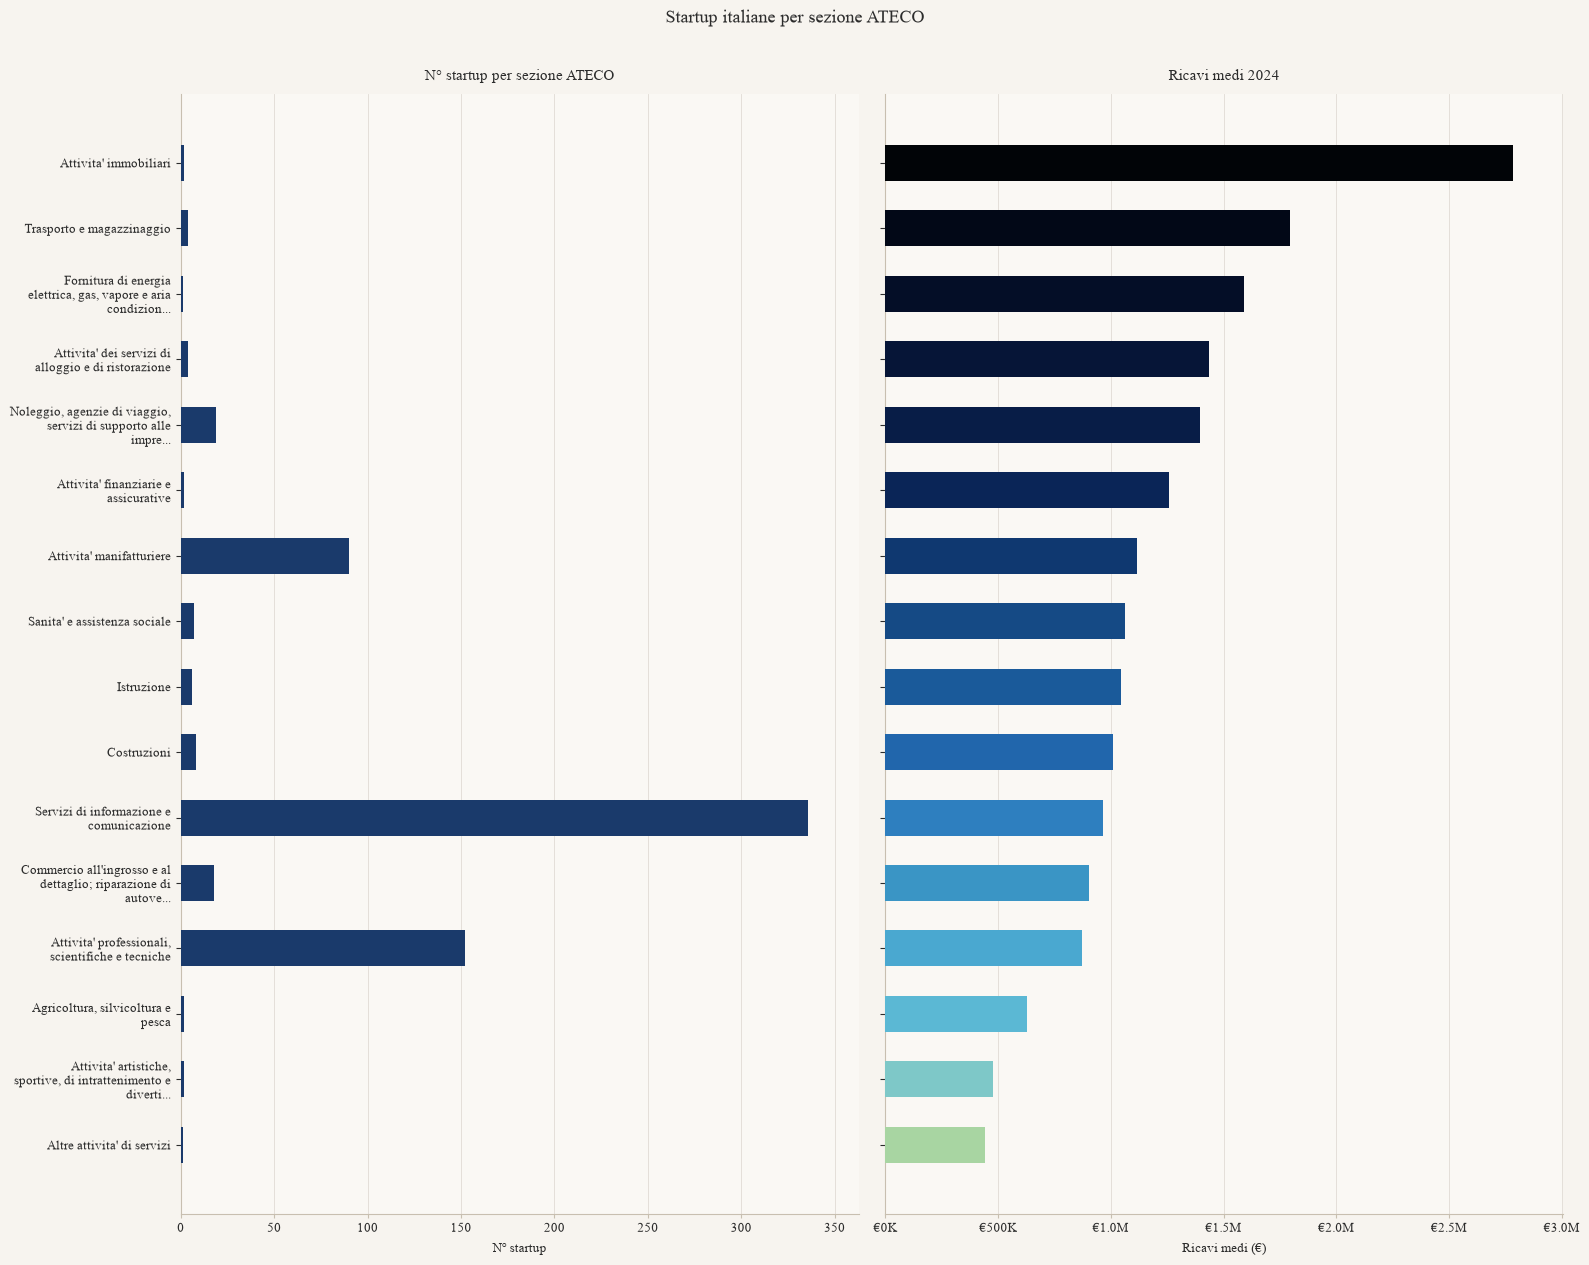

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import textwrap
import pandas as pd

# ── 1. PULIZIA & AGGREGAZIONE ────────────────────────────────
df['ricavi_2024'] = pd.to_numeric(
    df['Ricavi vendite e prestazioni migl EUR 2024'], errors='coerce'
) * 1000

def clean_label(s):
    return str(s).strip().capitalize()

agg = (
    df.groupby('ateco_sezione_desc')
    .agg(
        n_startup  = ('ragione_sociale', 'count'),
        ricavi_medi= ('ricavi_2024',     'mean'),
    )
    .reset_index()
    .sort_values('ricavi_medi', ascending=True)
)
agg['label_clean'] = agg['ateco_sezione_desc'].apply(clean_label)

# ── 2. PALETTE ────────────────────────────────────────────────
RIGHT_COLORS = [
    "#a8d5a2", "#7ec8c8", "#5bb8d4", "#4aa8d0", "#3a95c5",
    "#2e7fbf", "#2166ac", "#1a5a9a", "#154a85", "#0f3870",
    "#0a2557", "#081d47", "#061537", "#040e27", "#020817",
    "#010407",
]
n = len(agg)
colors_right = RIGHT_COLORS[:n]
BAR_COLOR_LEFT = "#1a3a6b"

labels = [textwrap.fill(s, width=30) for s in agg['label_clean']]
y_pos  = np.arange(n)

FONT        = "Times New Roman"
BG_FIG      = "#f7f4ef"
BG_AX       = "#faf8f4"
TEXT_COLOR  = "#2c2c2c"
GRID_COLOR  = "#e0dbd4"
SPINE_COLOR = "#c8bfb0"

# ── 3. FIGURA ─────────────────────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(
    1, 2,
    figsize=(16, max(6, n * 0.78)),
    facecolor=BG_FIG,
)
fig.subplots_adjust(wspace=0.06)

for ax in (ax_l, ax_r):
    ax.set_facecolor(BG_AX)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_color(SPINE_COLOR)

# ── Pannello sinistro ─────────────────────────────────────────
ax_l.barh(y_pos, agg['n_startup'], color=BAR_COLOR_LEFT,
          height=0.55, zorder=3)

ax_l.set_yticks(y_pos)
ax_l.set_yticklabels(labels, fontsize=9.5, fontfamily=FONT,
                     color=TEXT_COLOR)
ax_l.set_title("N° startup per sezione ATECO", fontsize=11,
               fontfamily=FONT, pad=10, color=TEXT_COLOR)

max_n = agg['n_startup'].max()
step  = 50 if max_n > 200 else (20 if max_n > 50 else 10)
ticks_l = np.arange(0, max_n + step, step)
ax_l.set_xticks(ticks_l)
ax_l.set_xticklabels([str(int(t)) for t in ticks_l],
                     fontsize=9, fontfamily=FONT, color=TEXT_COLOR)
ax_l.set_xlabel("N° startup", fontsize=9.5, fontfamily=FONT,
                labelpad=6, color=TEXT_COLOR)
ax_l.tick_params(axis='x', length=3, color=SPINE_COLOR)
ax_l.set_xlim(0, max_n * 1.08)
ax_l.spines[['top', 'right']].set_visible(False)
ax_l.grid(axis='x', color=GRID_COLOR, linewidth=0.6, zorder=0)

# ── Pannello destro ───────────────────────────────────────────
ax_r.barh(y_pos, agg['ricavi_medi'], color=colors_right,
          height=0.55, zorder=3)

ax_r.set_yticks(y_pos)
ax_r.set_yticklabels([])
ax_r.set_title("Ricavi medi 2024", fontsize=11,
               fontfamily=FONT, pad=10, color=TEXT_COLOR)

ax_r.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"€{x/1_000_000:.1f}M" if x >= 1_000_000
                     else f"€{int(x/1_000)}K"
    )
)
ax_r.tick_params(axis='x', labelsize=9, length=3, color=SPINE_COLOR)
ax_r.set_xlabel("Ricavi medi (€)", fontsize=9.5, fontfamily=FONT,
                labelpad=6, color=TEXT_COLOR)
for lbl in ax_r.get_xticklabels():
    lbl.set_fontfamily(FONT)
    lbl.set_color(TEXT_COLOR)

ax_r.spines[['top', 'right']].set_visible(False)
ax_r.grid(axis='x', color=GRID_COLOR, linewidth=0.6, zorder=0)
ax_r.set_xlim(0, agg['ricavi_medi'].max() * 1.08)

# ── Titolo ────────────────────────────────────────────────────
fig.suptitle(
    "Startup italiane per sezione ATECO",
    fontsize=13, fontfamily=FONT, color=TEXT_COLOR, y=1.01
)

plt.tight_layout()
plt.savefig("startup_ateco.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### DISTRIBUZIONE DELLO STADIO DI SVILUPPO

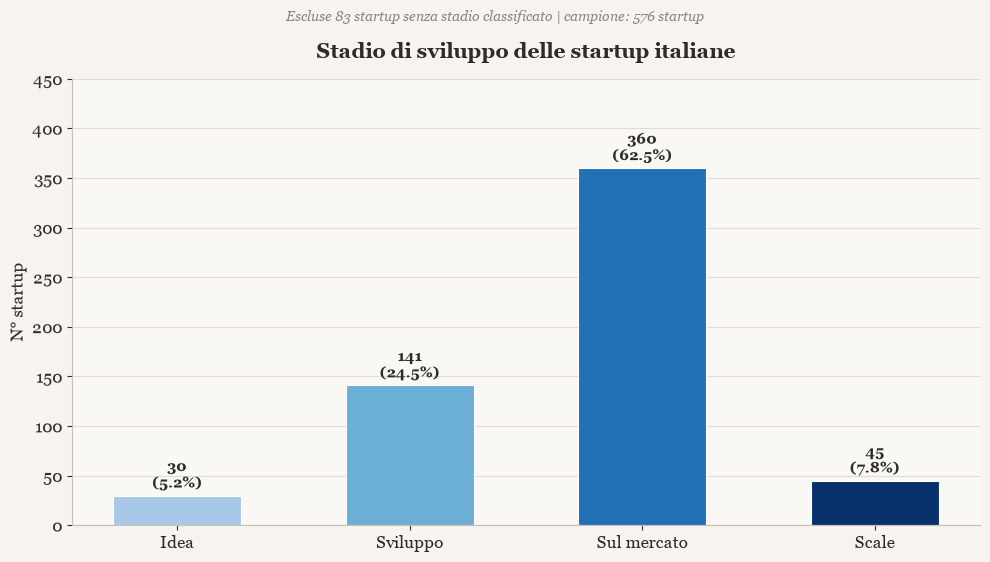

In [39]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

# ── 1. PULIZIA ───────────────────────────────────────────────
df_stadio = df[df['stadio_startup'].notna()].copy()

ordine_stadio = ['Idea', 'Sviluppo', 'Sul mercato', 'Scale']
colori_stadio = ['#a8c8e8', '#6baed6', '#2171b5', '#08306b']

agg_stadio = (
    df_stadio.groupby('stadio_startup')
    .size()
    .reset_index(name='n')
)
agg_stadio['stadio_startup'] = pd.Categorical(
    agg_stadio['stadio_startup'], categories=ordine_stadio, ordered=True
)
agg_stadio = agg_stadio.sort_values('stadio_startup').reset_index(drop=True)
agg_stadio['pct'] = (agg_stadio['n'] / agg_stadio['n'].sum() * 100).round(1)

# ── 2. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')

bars = ax.bar(
    agg_stadio['stadio_startup'].astype(str),
    agg_stadio['n'],
    color=colori_stadio,
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

# Etichette sopra ogni barra
for bar, (_, row) in zip(bars, agg_stadio.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f"{int(row['n'])}\n({row['pct']}%)",
        ha='center', va='bottom',
        fontsize=11, color='#2c2c2c',
        fontweight='bold'
    )

# ── 3. STILE ─────────────────────────────────────────────────
ax.set_title(
    'Stadio di sviluppo delle startup italiane',
    fontsize=15, color='#2c2c2c', pad=15, fontweight='bold'
)
fig.text(
    0.5, 0.91,
    'Escluse 83 startup senza stadio classificato | campione: 576 startup',
    ha='center', fontsize=10, color='#888888', style='italic'
)
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('N° startup', fontsize=12, color='#2c2c2c')
ax.tick_params(labelsize=12, colors='#2c2c2c')
ax.set_ylim(0, agg_stadio['n'].max() * 1.25)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

#### Versione 2

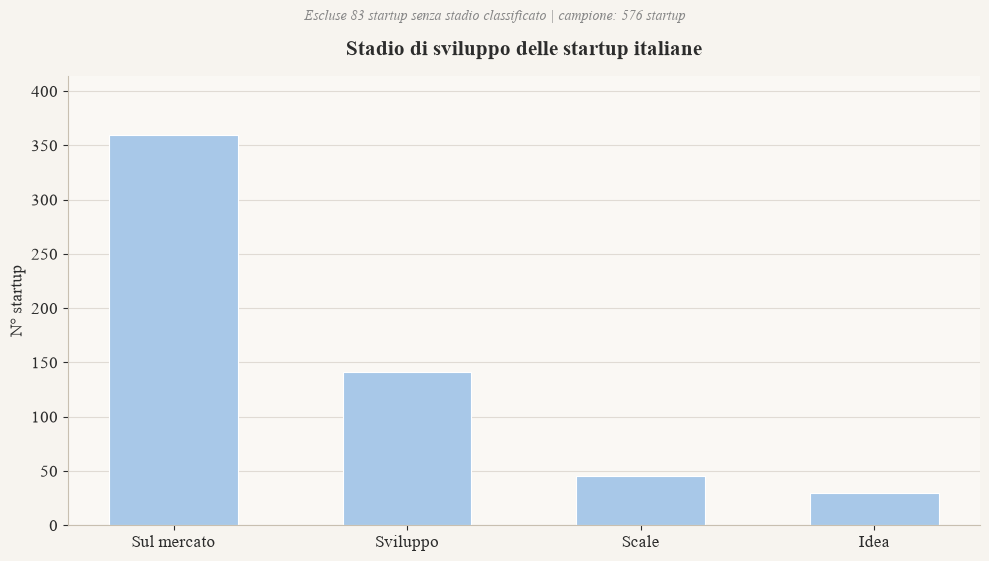

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'

# ── 1. PULIZIA ───────────────────────────────────────────────
df_stadio = df[df['stadio_startup'].notna()].copy()

agg_stadio = (
    df_stadio.groupby('stadio_startup')
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .reset_index(drop=True)
)
agg_stadio['pct'] = (agg_stadio['n'] / agg_stadio['n'].sum() * 100).round(1)

# ── 2. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')

ax.bar(
    agg_stadio['stadio_startup'].astype(str),
    agg_stadio['n'],
    color='#a8c8e8',
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

# ── 3. STILE ─────────────────────────────────────────────────
ax.set_title(
    'Stadio di sviluppo delle startup italiane',
    fontsize=15, color='#2c2c2c', pad=15, fontweight='bold'
)
fig.text(
    0.5, 0.91,
    'Escluse 83 startup senza stadio classificato | campione: 576 startup',
    ha='center', fontsize=10, color='#888888', style='italic'
)
ax.set_ylabel('N° startup', fontsize=12, color='#2c2c2c')
ax.tick_params(labelsize=12, colors='#2c2c2c')
ax.set_ylim(0, agg_stadio['n'].max() * 1.15)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

### DISTRIBUZIONE DELLA DIMENSIONE DELL'AZIENDA

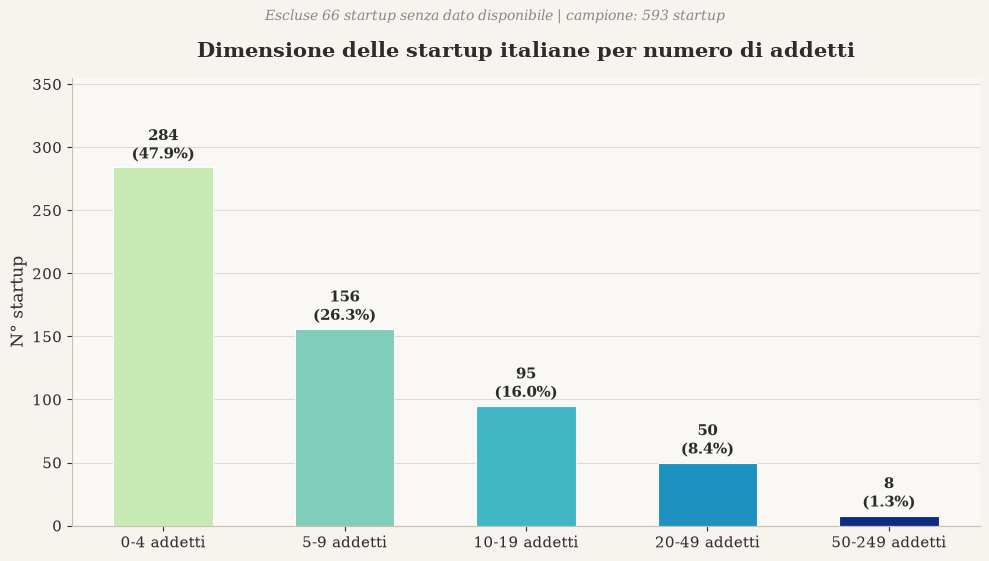

In [35]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# Font serif coerente con lo stile degli altri grafici
mpl.rcParams['font.family'] = 'serif'

# ── 1. PULIZIA ───────────────────────────────────────────────
df_dim = df[df['classe_addetti'] != 'non disponibile'].copy()

ordine_addetti = ['0-4 addetti', '5-9 addetti', '10-19 addetti',
                  '20-49 addetti', '50-249 addetti']
colori_addetti = ['#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#0c2c84']

agg_dim = (
    df_dim.groupby('classe_addetti')
    .size()
    .reset_index(name='n')
)
agg_dim['classe_addetti'] = pd.Categorical(
    agg_dim['classe_addetti'], categories=ordine_addetti, ordered=True
)
agg_dim = agg_dim.sort_values('classe_addetti').reset_index(drop=True)
agg_dim['pct'] = (agg_dim['n'] / agg_dim['n'].sum() * 100).round(1)

# ── 2. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')

bars = ax.bar(
    agg_dim['classe_addetti'].astype(str),
    agg_dim['n'],
    color=colori_addetti,
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

# Etichette sopra ogni barra
for bar, (_, row) in zip(bars, agg_dim.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{int(row['n'])}\n({row['pct']}%)",
        ha='center', va='bottom',
        fontsize=11, color='#2c2c2c',
        fontweight='bold'
    )

# ── 3. STILE ─────────────────────────────────────────────────
ax.set_title(
    'Dimensione delle startup italiane per numero di addetti',
    fontsize=15, color='#2c2c2c', pad=15, fontweight='bold'
)
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('N° startup', fontsize=12, color='#2c2c2c')

# Sottotitolo manuale
fig.text(
    0.5, 0.91,
    'Escluse 66 startup senza dato disponibile | campione: 593 startup',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.tick_params(labelsize=11, colors='#2c2c2c')
ax.set_ylim(0, agg_dim['n'].max() * 1.25)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

### da togliere

### TREND DI NASCITA DELLE STARTUP: QUANTE NASCONO PER OGNI ANNO CONSIDERATO

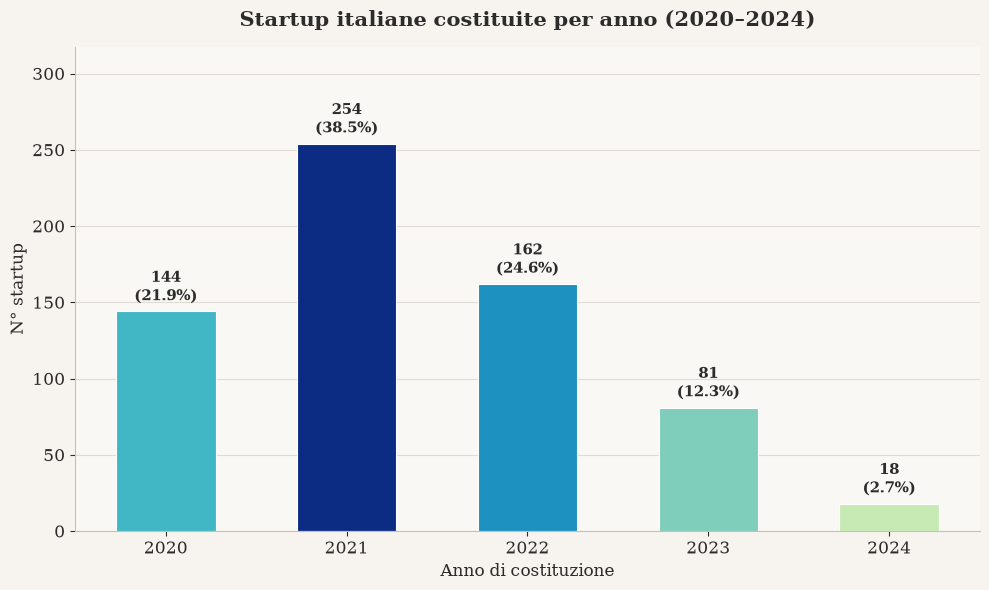

In [37]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'serif'

# ── 1. PULIZIA ───────────────────────────────────────────────
df['anno_cost'] = pd.to_datetime(df['data costituzione'], errors='coerce').dt.year

agg_anni = (
    df.groupby('anno_cost')
    .size()
    .reset_index(name='n')
    .sort_values('anno_cost')
    .reset_index(drop=True)
)
agg_anni['pct'] = (agg_anni['n'] / agg_anni['n'].sum() * 100).round(1)
agg_anni['anno_str'] = agg_anni['anno_cost'].astype(int).astype(str)

# ── 2. COLORI — gradazione teal/verde acqua, tutti visibili ──
# Assegna manualmente 5 toni ben distanziati sulla scala
colori_fissi = ['#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#0c2c84']
# Dal più chiaro al più scuro in ordine crescente di n
ordine_per_n = agg_anni['n'].rank(method='first').astype(int) - 1
colori = [colori_fissi[i] for i in ordine_per_n]

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')

bars = ax.bar(
    agg_anni['anno_str'],
    agg_anni['n'],
    color=colori,
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

# Etichette sopra ogni barra
for bar, (_, row) in zip(bars, agg_anni.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f"{int(row['n'])}\n({row['pct']}%)",
        ha='center', va='bottom',
        fontsize=11, color='#2c2c2c',
        fontweight='bold'
    )

# ── 4. STILE ─────────────────────────────────────────────────
ax.set_title(
    'Startup italiane costituite per anno (2020–2024)',
    fontsize=15, color='#2c2c2c', pad=15, fontweight='bold'
)
ax.set_xlabel('Anno di costituzione', fontsize=12, color='#2c2c2c')
ax.set_ylabel('N° startup', fontsize=12, color='#2c2c2c')
ax.tick_params(labelsize=12, colors='#2c2c2c')
ax.set_ylim(0, agg_anni['n'].max() * 1.25)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.tight_layout()
plt.show()

### Versione 2

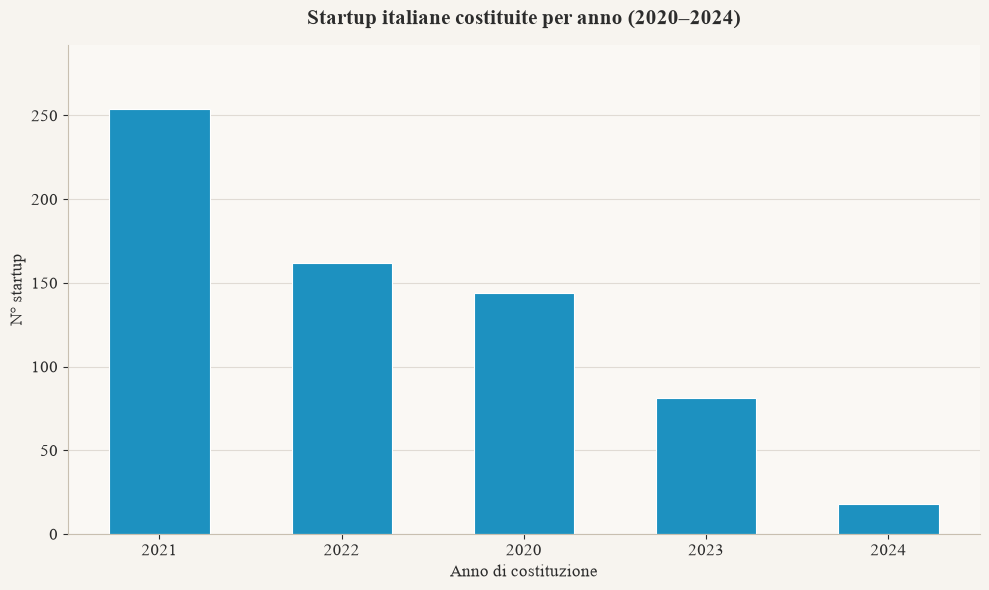

In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'

# ── 1. PULIZIA ───────────────────────────────────────────────
df['anno_cost'] = pd.to_datetime(df['data costituzione'], errors='coerce').dt.year

agg_anni = (
    df.groupby('anno_cost')
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .reset_index(drop=True)
)
agg_anni['anno_str'] = agg_anni['anno_cost'].astype(int).astype(str)

# ── 2. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')

ax.bar(
    agg_anni['anno_str'],
    agg_anni['n'],
    color='#1d91c0',
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

# ── 3. STILE ─────────────────────────────────────────────────
ax.set_title(
    'Startup italiane costituite per anno (2020–2024)',
    fontsize=15, color='#2c2c2c', pad=15, fontweight='bold'
)
ax.set_xlabel('Anno di costituzione', fontsize=12, color='#2c2c2c')
ax.set_ylabel('N° startup', fontsize=12, color='#2c2c2c')
ax.tick_params(labelsize=12, colors='#2c2c2c')
ax.set_ylim(0, agg_anni['n'].max() * 1.15)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.tight_layout()
plt.show()

### COME SI FINANZIANO

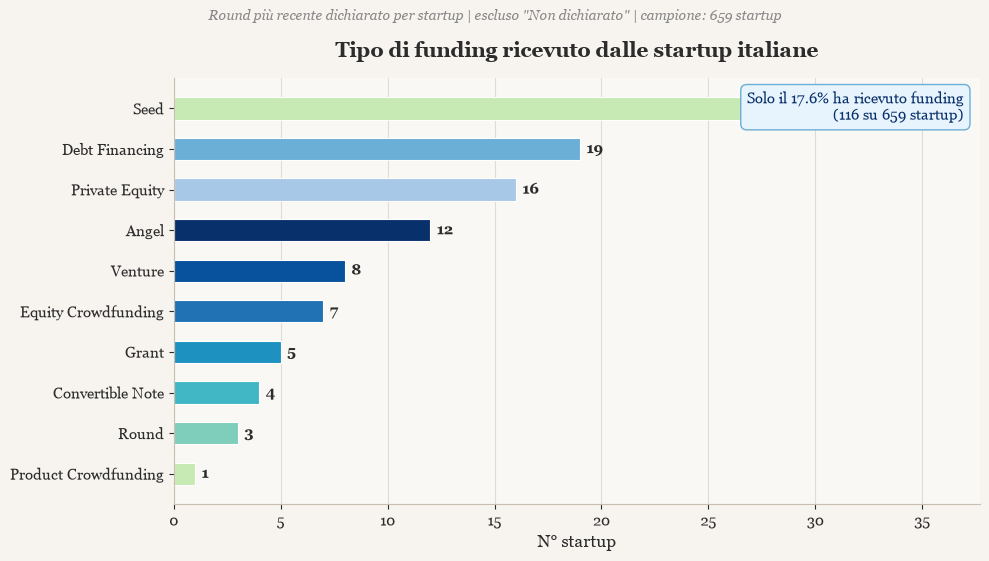

In [41]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'
    
df['finanza_ammontare_euro'] = pd.to_numeric(df['finanza_ammontare_euro'], errors='coerce')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# GRAFICO 1 — TIPO DI FUNDING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

n_tot        = len(df)
n_funded     = df['finanza'].notna().sum()

tipo_funding = (
    df['finanza']
    .dropna()
    .where(df['finanza'] != 'Non dichiarato')
    .dropna()
    .value_counts()
    .sort_values(ascending=True)
)

colori_tipo = [
    '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0',
    '#2171b5', '#08519c', '#08306b', '#a8c8e8', '#6baed6'
][:len(tipo_funding)]

fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor('#f7f4ef')
ax1.set_facecolor('#faf8f4')

bars = ax1.barh(
    tipo_funding.index,
    tipo_funding.values,
    color=colori_tipo,
    edgecolor='white',
    linewidth=0.8,
    height=0.55,
)

for bar, val in zip(bars, tipo_funding.values):
    ax1.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(int(val)),
        va='center', ha='left',
        fontsize=11, color='#2c2c2c', fontweight='bold'
    )

ax1.text(
    0.98, 0.97,
    f"Solo il {n_funded/n_tot*100:.1f}% ha ricevuto funding\n"
    f"({n_funded} su {n_tot} startup)",
    transform=ax1.transAxes,
    ha='right', va='top',
    fontsize=11, color='#08306b',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f4fd',
              edgecolor='#6baed6', linewidth=1)
)

ax1.set_title(
    'Tipo di funding ricevuto dalle startup italiane',
    fontsize=15, color='#2c2c2c', pad=15, fontweight='bold'
)
fig1.text(
    0.5, 0.91,
    'Round più recente dichiarato per startup | escluso "Non dichiarato" | campione: 659 startup',
    ha='center', fontsize=10, color='#888888', style='italic'
)
ax1.set_xlabel('N° startup', fontsize=12, color='#2c2c2c')
ax1.set_ylabel('')
ax1.tick_params(labelsize=11, colors='#2c2c2c')
ax1.set_xlim(0, tipo_funding.max() * 1.3)
ax1.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#c8bfb0')
ax1.spines['bottom'].set_color('#c8bfb0')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

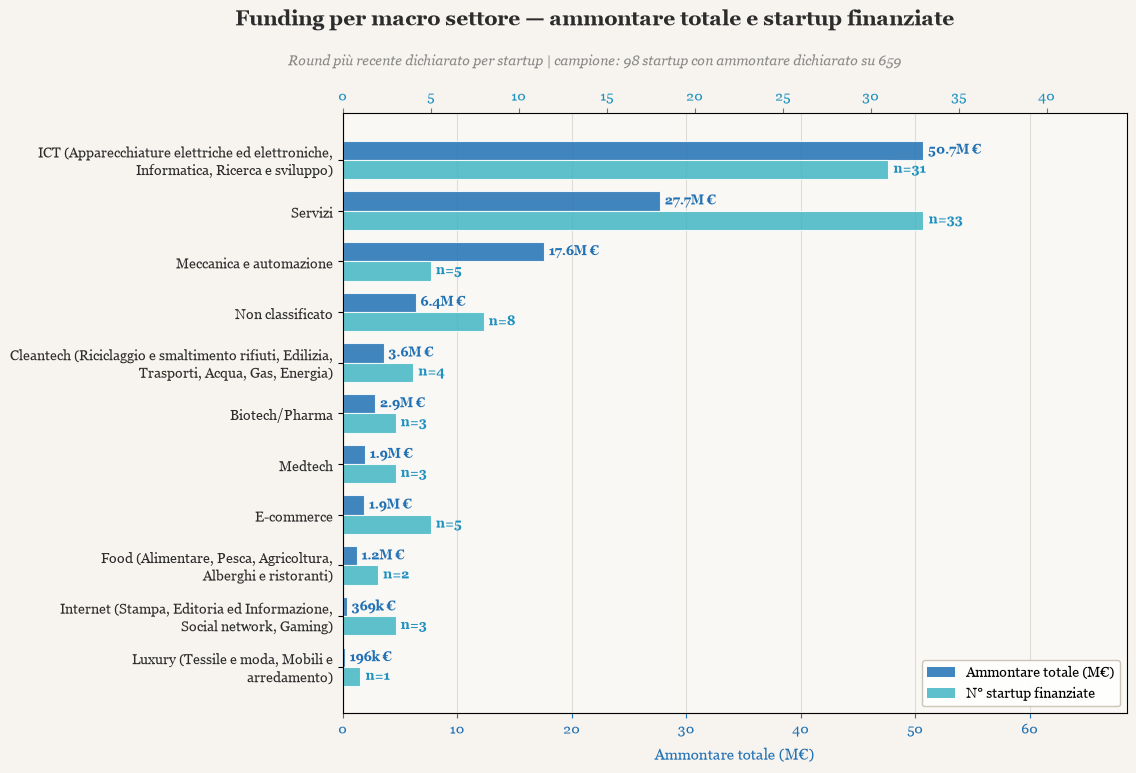

In [45]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df['finanza_ammontare_euro'] = pd.to_numeric(df['finanza_ammontare_euro'], errors='coerce')

funded = df[df['finanza_ammontare_euro'].notna()].copy()

agg_settore = (
    funded.groupby('macro_settore')
    .agg(
        ammontare_totale=('finanza_ammontare_euro', 'sum'),
        n_startup=('finanza_ammontare_euro', 'count'),
    )
    .reset_index()
    .sort_values('ammontare_totale', ascending=True)
    .reset_index(drop=True)
)

agg_settore['ammontare_fmt'] = agg_settore['ammontare_totale'].apply(
    lambda x: f"{x/1_000_000:.1f}M €" if x >= 1_000_000 else f"{x/1000:.0f}k €"
)

def wrap_label(text, max_len=30):
    if len(text) <= max_len:
        return text
    mid = len(text) // 2
    split = text.rfind(' ', 0, mid + 15)
    if split == -1:
        split = mid
    return text[:split] + '\n' + text[split+1:]

agg_settore['label'] = agg_settore['macro_settore'].apply(wrap_label)

fig2, ax_left = plt.subplots(figsize=(14, 8))
fig2.patch.set_facecolor('#f7f4ef')
ax_left.set_facecolor('#faf8f4')

fig2.subplots_adjust(left=0.32, right=0.88, top=0.85, bottom=0.10)

y      = np.arange(len(agg_settore))
height = 0.38

bars_amt = ax_left.barh(
    y + height / 2,
    agg_settore['ammontare_totale'] / 1_000_000,
    height=height,
    color='#2171b5',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
)

ax_right = ax_left.twiny()
bars_n = ax_right.barh(
    y - height / 2,
    agg_settore['n_startup'],
    height=height,
    color='#41b6c4',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
)

for bar, val in zip(bars_amt, agg_settore['ammontare_fmt']):
    ax_left.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        val,
        va='center', ha='left',
        fontsize=9, color='#2171b5', fontweight='bold'
    )

for bar, val in zip(bars_n, agg_settore['n_startup']):
    ax_right.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"n={int(val)}",
        va='center', ha='left',
        fontsize=9, color='#1d91c0', fontweight='bold'
    )

ax_left.set_yticks(y)
ax_left.set_yticklabels(agg_settore['label'], fontsize=10, color='#2c2c2c', linespacing=1.3)

legend_elements = [
    mpatches.Patch(facecolor='#2171b5', alpha=0.85, label='Ammontare totale (M€)'),
    mpatches.Patch(facecolor='#41b6c4', alpha=0.85, label='N° startup finanziate'),
]
ax_left.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=10,
    framealpha=0.9,
    edgecolor='#c8bfb0',
)

# ── FIX: titoli assi separati e ben posizionati ──────────────
ax_left.set_xlabel('Ammontare totale (M€)', fontsize=11, color='#2171b5', labelpad=8)
ax_right.set_xlabel('') 

ax_left.tick_params(axis='x', colors='#2171b5', labelsize=10)
ax_right.tick_params(axis='x', colors='#1d91c0', labelsize=10)
ax_left.set_xlim(0, agg_settore['ammontare_totale'].max() / 1_000_000 * 1.35)
ax_right.set_xlim(0, agg_settore['n_startup'].max() * 1.35)

# Titolo e sottotitolo
fig2.text(
    0.5, 0.96,
    'Funding per macro settore — ammontare totale e startup finanziate',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig2.text(
    0.5, 0.91,
    'Round più recente dichiarato per startup | campione: 98 startup con ammontare dichiarato su 659',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax_left.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax_left.set_axisbelow(True)
ax_left.spines['top'].set_visible(False)
ax_left.spines['right'].set_visible(False)
ax_left.spines['left'].set_color('#c8bfb0')
ax_left.spines['bottom'].set_color('#c8bfb0')

plt.show()

### Versione 2:

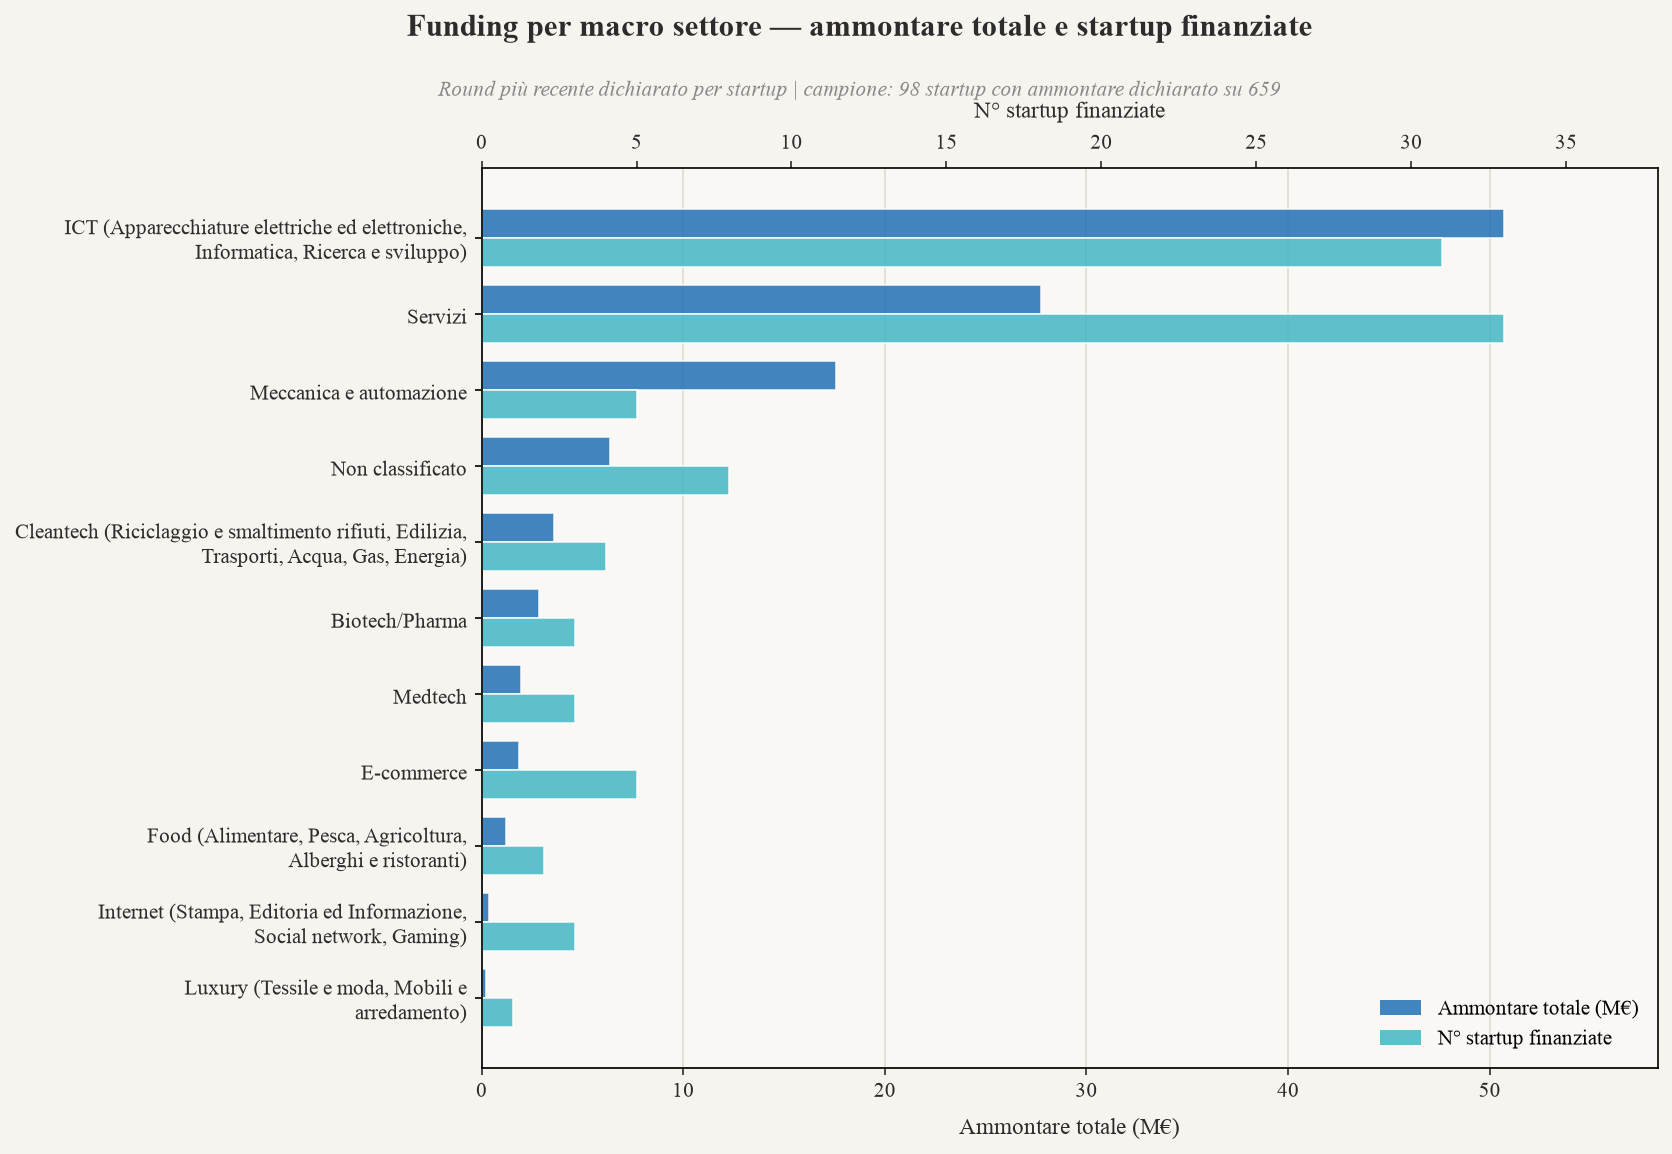

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

# ── 1. PULIZIA ───────────────────────────────────────────────
df['finanza_ammontare_euro'] = pd.to_numeric(df['finanza_ammontare_euro'], errors='coerce')

funded = df[df['finanza_ammontare_euro'].notna()].copy()

agg_settore = (
    funded.groupby('macro_settore')
    .agg(
        ammontare_totale=('finanza_ammontare_euro', 'sum'),
        n_startup=('finanza_ammontare_euro', 'count'),
    )
    .reset_index()
    .sort_values('ammontare_totale', ascending=True)
    .reset_index(drop=True)
)

def wrap_label(text, max_len=30):
    if len(text) <= max_len:
        return text
    mid = len(text) // 2
    split = text.rfind(' ', 0, mid + 15)
    if split == -1:
        split = mid
    return text[:split] + '\n' + text[split+1:]

agg_settore['label'] = agg_settore['macro_settore'].apply(wrap_label)

# ── 2. FIGURA ────────────────────────────────────────────────
fig2, ax_left = plt.subplots(figsize=(14, 8))
fig2.patch.set_facecolor('#f7f4ef')
ax_left.set_facecolor('#faf8f4')
fig2.subplots_adjust(left=0.32, right=0.88, top=0.85, bottom=0.10)

y      = np.arange(len(agg_settore))
height = 0.38

ax_left.barh(
    y + height / 2,
    agg_settore['ammontare_totale'] / 1_000_000,
    height=height,
    color='#2171b5',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
)

ax_right = ax_left.twiny()
ax_right.barh(
    y - height / 2,
    agg_settore['n_startup'],
    height=height,
    color='#41b6c4',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
)

# ── 3. ASSI ──────────────────────────────────────────────────
ax_left.set_yticks(y)
ax_left.set_yticklabels(agg_settore['label'], fontsize=10,
                        color='#2c2c2c', linespacing=1.3)

ax_left.set_xlabel('Ammontare totale (M€)', fontsize=11,
                   color='#2c2c2c', labelpad=8)
ax_right.set_xlabel('N° startup finanziate', fontsize=11,
                    color='#2c2c2c', labelpad=8)

ax_left.tick_params(axis='x', colors='#2c2c2c', labelsize=10)
ax_right.tick_params(axis='x', colors='#2c2c2c', labelsize=10)
ax_left.set_xlim(0, agg_settore['ammontare_totale'].max() / 1_000_000 * 1.15)
ax_right.set_xlim(0, agg_settore['n_startup'].max() * 1.15)

# ── 4. LEGENDA senza box ──────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='#2171b5', alpha=0.85, label='Ammontare totale (M€)'),
    mpatches.Patch(facecolor='#41b6c4', alpha=0.85, label='N° startup finanziate'),
]
ax_left.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=10,
    frameon=False,
)

# ── 5. TITOLI ─────────────────────────────────────────────────
fig2.text(
    0.5, 0.96,
    'Funding per macro settore — ammontare totale e startup finanziate',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig2.text(
    0.5, 0.91,
    'Round più recente dichiarato per startup | campione: 98 startup con ammontare dichiarato su 659',
    ha='center', fontsize=10, color='#888888', style='italic'
)

# ── 6. STILE ─────────────────────────────────────────────────
ax_left.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax_left.set_axisbelow(True)
ax_left.spines['top'].set_visible(False)
ax_left.spines['right'].set_visible(False)
ax_left.spines['left'].set_color('#c8bfb0')
ax_left.spines['bottom'].set_color('#c8bfb0')

plt.show()

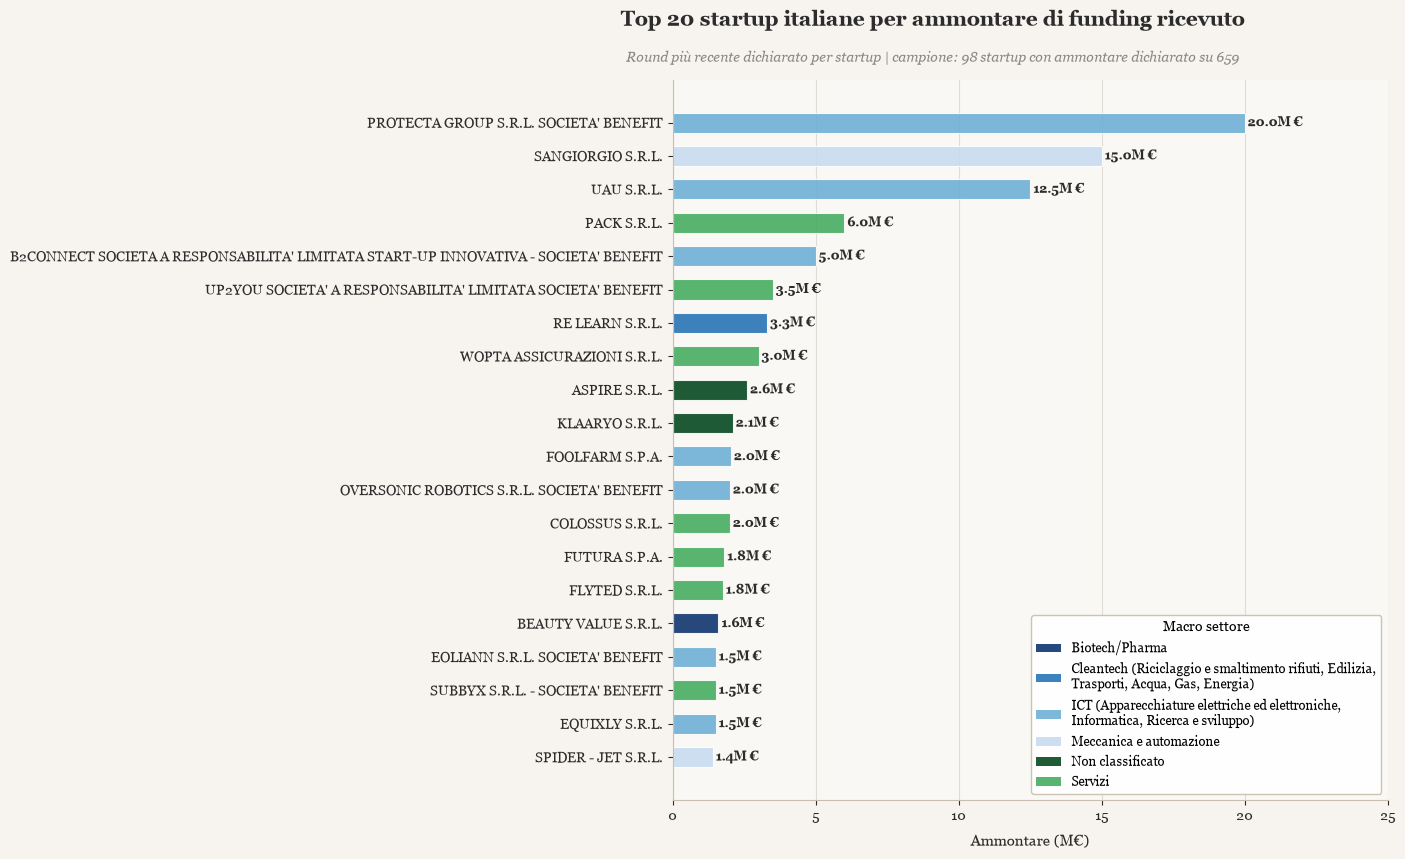

In [46]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df['finanza_ammontare_euro'] = pd.to_numeric(df['finanza_ammontare_euro'], errors='coerce')

# ── 1. PREP DATI ─────────────────────────────────────────────
top20 = (
    df[df['finanza_ammontare_euro'].notna()]
    .sort_values('finanza_ammontare_euro', ascending=True)
    .tail(20)
    .reset_index(drop=True)
)

top20['ammontare_fmt'] = top20['finanza_ammontare_euro'].apply(
    lambda x: f"{x/1_000_000:.1f}M €" if x >= 1_000_000 else f"{x/1000:.0f}k €"
)

# ── 2. COLORI PER MACRO SETTORE ───────────────────────────────
settori_unici = sorted(top20['macro_settore'].dropna().unique())
palette = [
    '#08306b', '#2171b5', '#6baed6', '#c6dbef',
    '#00441b', '#41ab5d', '#a1d99b',
    '#7f2704', '#d94801', '#fdae6b',
    '#3f007d', '#807dba',
]
color_map = {s: palette[i % len(palette)] for i, s in enumerate(settori_unici)}
top20['color'] = top20['macro_settore'].map(color_map)

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.30, right=0.85, top=0.88, bottom=0.08)

bars = ax.barh(
    top20['ragione_sociale'],
    top20['finanza_ammontare_euro'] / 1_000_000,
    color=top20['color'],
    edgecolor='white',
    linewidth=0.8,
    height=0.6,
    alpha=0.88,
)

# Etichette ammontare a destra
for bar, val in zip(bars, top20['ammontare_fmt']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        val,
        va='center', ha='left',
        fontsize=9, color='#2c2c2c', fontweight='bold'
    )

# ── 4. LEGENDA MACRO SETTORE ──────────────────────────────────
settori_presenti = top20['macro_settore'].dropna().unique()

def wrap_label(text, max_len=28):
    if len(text) <= max_len:
        return text
    mid = len(text) // 2
    split = text.rfind(' ', 0, mid + 15)
    if split == -1:
        split = mid
    return text[:split] + '\n' + text[split+1:]

legend_elements = [
    mpatches.Patch(
        facecolor=color_map[s],
        alpha=0.88,
        label=wrap_label(s)
    )
    for s in sorted(settori_presenti)
]
ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=9,
    framealpha=0.92,
    edgecolor='#c8bfb0',
    title='Macro settore',
    title_fontsize=10,
)

# ── 5. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.94,
    'Top 20 startup italiane per ammontare di funding ricevuto',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.90,
    'Round più recente dichiarato per startup | campione: 98 startup con ammontare dichiarato su 659',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_xlabel('Ammontare (M€)', fontsize=11, color='#2c2c2c', labelpad=8)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.tick_params(axis='x', labelsize=10, colors='#2c2c2c')
ax.set_xlim(0, top20['finanza_ammontare_euro'].max() / 1_000_000 * 1.25)
ax.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### Questo mi sa scartiamo (quello su)

### DIVERSITA DELL'ECOSISTEMA

In [51]:
import plotly.graph_objects as go
import pandas as pd

# ── 1. PREP DATI ─────────────────────────────────────────────
n_tot = len(df)

dimensioni = {
    'Prevalenza femminile': 'prevalenza_femminile',
    'Prevalenza giovanile': 'prevalenza_giovanile',
    'Prevalenza straniera': 'prevalenza_straniera',
}

livelli = ['Forte', 'Maggioritaria', 'Esclusiva']
colori  = ['#6baed6', '#2171b5', '#08306b']
soglie  = {'Forte': '> 50%', 'Maggioritaria': '> 66%', 'Esclusiva': '100%'}

records = []
for label, col in dimensioni.items():
    for livello in livelli:
        n = (df[col] == livello).sum()
        records.append({
            'dimensione': label,
            'livello': livello,
            'n': n,
            'pct': round(n / n_tot * 100, 1)
        })

agg = pd.DataFrame(records)

# ── 2. FIGURA ────────────────────────────────────────────────
fig = go.Figure()

dim_labels = list(dimensioni.keys())

for livello, colore in zip(livelli, colori):
    subset = agg[agg['livello'] == livello]
    vals   = [subset[subset['dimensione'] == d]['n'].values[0] for d in dim_labels]
    pcts   = [subset[subset['dimensione'] == d]['pct'].values[0] for d in dim_labels]

    fig.add_trace(go.Bar(
        name=f"{livello} ({soglie[livello]})",
        y=dim_labels,
        x=vals,
        orientation='h',
        marker=dict(color=colore, opacity=0.88, line=dict(width=0.5, color='white')),
        customdata=[[v, p, livello, soglie[livello]] for v, p in zip(vals, pcts)],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Livello: <b>%{customdata[2]}</b> (%{customdata[3]} della compagine societaria)<br>"
            "Startup: <b>%{customdata[0]}</b><br>"
            "Sul totale campione: <b>%{customdata[1]}%</b>"
            "<extra></extra>"
        ),
        text=[f"{v}" if v > 0 else '' for v in vals],
        textposition='inside',
        textfont=dict(color='white', size=11, family='Georgia, serif'),
        insidetextanchor='middle',
    ))

# Totale per categoria come annotazione
for d in dim_labels:
    tot = agg[agg['dimensione'] == d]['n'].sum()
    pct = round(tot / n_tot * 100, 1)
    fig.add_annotation(
        y=d,
        x=tot,
        text=f"  <b>{tot}</b> startup ({pct}%)",
        showarrow=False,
        xanchor='left',
        font=dict(size=11, color='#2c2c2c', family='Georgia, serif'),
    )

# ── 3. LAYOUT ────────────────────────────────────────────────
fig.update_layout(
    barmode='stack',
    title=dict(
        text="Diversità dell'ecosistema startup italiano",
        font=dict(size=15, family='Georgia, serif', color='#2c2c2c'),
        x=0.5, xanchor='center', pad=dict(t=10)
    ),
    xaxis=dict(
        title='N° startup',
        title_font=dict(size=12, family='Georgia, serif'),
        tickfont=dict(size=11, family='Georgia, serif'),
        gridcolor='#e0dbd4',
        showline=True, linecolor='#c8bfb0',
        range=[0, 100],
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12, family='Georgia, serif'),
        automargin=True,
    ),
    legend=dict(
        title=dict(
            text='<b>Livello di prevalenza</b><br>'
                 '<i style="font-size:10px">% della compagine societaria</i>',
            font=dict(size=11, family='Georgia, serif'),
        ),
        bgcolor='rgba(247,244,239,0.92)',
        bordercolor='#c8bfb0',
        borderwidth=1,
        font=dict(size=11, family='Georgia, serif'),
        x=1.02, y=0.5,
        xanchor='left', yanchor='middle',
    ),
    paper_bgcolor='#f7f4ef',
    plot_bgcolor='#faf8f4',
    margin=dict(l=20, r=200, t=60, b=50),
    height=350,
)

fig.show()

### Versione 2

In [25]:
import plotly.graph_objects as go
import pandas as pd

mpl_font = 'Times New Roman, serif'

# ── 1. PREP DATI ─────────────────────────────────────────────
n_tot = len(df)

dimensioni = {
    'Prevalenza femminile': 'prevalenza_femminile',
    'Prevalenza giovanile': 'prevalenza_giovanile',
    'Prevalenza straniera': 'prevalenza_straniera',
}

livelli = ['Forte', 'Maggioritaria', 'Esclusiva']
colori  = ['#6baed6', '#2171b5', '#08306b']
soglie  = {'Forte': '> 50%', 'Maggioritaria': '> 66%', 'Esclusiva': '100%'}

records = []
for label, col in dimensioni.items():
    for livello in livelli:
        n = (df[col] == livello).sum()
        records.append({
            'dimensione': label,
            'livello': livello,
            'n': n,
            'pct': round(n / n_tot * 100, 1)
        })

agg = pd.DataFrame(records)
dim_labels = list(dimensioni.keys())

# ── 2. FIGURA ────────────────────────────────────────────────
fig = go.Figure()

for livello, colore in zip(livelli, colori):
    subset = agg[agg['livello'] == livello]
    vals   = [subset[subset['dimensione'] == d]['n'].values[0] for d in dim_labels]
    pcts   = [subset[subset['dimensione'] == d]['pct'].values[0] for d in dim_labels]

    fig.add_trace(go.Bar(
        name=f"{livello} ({soglie[livello]})",
        y=dim_labels,
        x=vals,
        orientation='h',
        marker=dict(color=colore, opacity=0.88, line=dict(width=0.5, color='white')),
        customdata=[[v, p, livello, soglie[livello]] for v, p in zip(vals, pcts)],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Livello: <b>%{customdata[2]}</b> (%{customdata[3]} della compagine societaria)<br>"
            "Startup: <b>%{customdata[0]}</b><br>"
            "Sul totale campione: <b>%{customdata[1]}%</b>"
            "<extra></extra>"
        ),
    ))

# ── 3. LAYOUT ────────────────────────────────────────────────
fig.update_layout(
    barmode='stack',
    title=dict(
        text="Diversità dell'ecosistema startup italiano",
        font=dict(size=15, family=mpl_font, color='#2c2c2c'),
        x=0.5, xanchor='center', pad=dict(t=10)
    ),
    xaxis=dict(
        title='N° startup',
        title_font=dict(size=12, family=mpl_font),
        tickfont=dict(size=11, family=mpl_font),
        gridcolor='#e0dbd4',
        showline=True, linecolor='#c8bfb0',
        range=[0, 100],
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12, family=mpl_font),
        automargin=True,
    ),
    legend=dict(
        title=dict(
            text='<b>Livello di prevalenza</b>',
            font=dict(size=11, family=mpl_font),
        ),
        bgcolor='rgba(247,244,239,0.92)',
        bordercolor='#c8bfb0',
        borderwidth=1,
        font=dict(size=11, family=mpl_font),
        x=1.02, y=0.5,
        xanchor='left', yanchor='middle',
    ),
    paper_bgcolor='#f7f4ef',
    plot_bgcolor='#faf8f4',
    margin=dict(l=20, r=220, t=60, b=50),
    height=350,
)

fig.show()